In [255]:
import re
import os
import pandas as pd
import numpy as np
from Bio import SeqIO
from datetime import datetime
from plotnine import *
from scipy import stats

In [195]:
# This script is intended to plot the population dynamics inferred by a BEAST model

In [196]:
# CONSTANT GROWTH

In [75]:
CONSTANTLOG = ""

In [76]:
constant_logdf = pd.read_csv(CONSTANTLOG, sep = "\t")

FileNotFoundError: [Errno 2] No such file or directory: ''

In [70]:
constant_popSize = constant_logdf["constant.popSize"].mean()
print(constant_popSize)

333


In [4]:
# EXPONENTIAL GROWTH

In [197]:
EXPLOG = "/Users/claramal/Desktop/Moncla_Lab/H5-genotypes/Plotting/exponential_pop_growth/h5_A3_emptree_exponential_MLE_2025-10-21_combined.log"

In [198]:
exp_logdf = pd.read_csv(EXPLOG, sep = "\t")

In [199]:
exp_logdf.head()

,state,joint,prior,likelihood,rootHeight,age(root),treeLength,exponential.popSize,exponential.growthRate,kappa,...,frequencies4,alpha,ucld.mean,ucld.stdev,meanRate,coefficientOfVariation,covariance,treeLikelihood,branchRates,coalescent
0,100000,-34039.862480,-2213.327321,-31826.535159,3.125638,2021.795127,45.261313,8.338429,0.516241,12.645494,...,0.236779,0.277306,0.002353,0.001405,0.002450,0.552753,-0.128850,-31826.535159,-1859.405598,-342.419456
1,200000,-34008.674640,-2187.082420,-31821.592220,3.034963,2021.885802,42.143303,8.238530,0.586637,9.695811,...,0.233848,0.273491,0.002864,0.001600,0.002604,0.590942,-0.001029,-31821.592220,-1859.405598,-316.549226
2,300000,-34021.717889,-2201.786854,-31819.931034,3.212996,2021.707769,44.418463,8.566969,0.545844,9.620527,...,0.227224,0.286970,0.002949,0.002342,0.002590,0.752357,-0.032025,-31819.931034,-1859.405598,-331.201061
3,400000,-34017.238930,-2195.845500,-31821.393429,3.155850,2021.764915,43.331309,11.852267,0.738848,10.833663,...,0.238072,0.256424,0.003280,0.001949,0.002840,0.574991,-0.057596,-31821.393429,-1859.405598,-324.696424
4,500000,-34020.654178,-2200.104462,-31820.549716,3.075991,2021.844774,43.863606,15.044232,0.848150,9.730770,...,0.230965,0.256928,0.002741,0.001697,0.002661,0.579123,0.013693,-31820.549716,-1859.405598,-329.029076


In [203]:
# Calculate the mean exponential growth rate and 95% HPD

def calculate_expPopSize(dtfm):

    exponential_popSize = {}
    initial_popSize = []
    growth_rate = []
    root_time = []

    for idx, row in dtfm.iterrows():
        tree_number = float(row["state"].astype(str).replace("0", ""))
        root_time.append(row["age(root)"])
        initial_popSize.append(row["exponential.popSize"])
        growth_rate.append(row["exponential.growthRate"])

    avg_root_time = np.mean(root_time)

    mean_initial = np.mean(initial_popSize)
    ci_lower_initial, ci_upper_initial = stats.t.interval(confidence=0.95, df=len(initial_popSize) - 1, loc=mean_initial, scale=stats.sem(initial_popSize))

    mean_rate = np.mean(growth_rate)
    ci_lower_rate, ci_upper_rate = stats.t.interval(confidence=0.95, df=len(growth_rate) - 1, loc=mean_rate, scale=stats.sem(growth_rate))
    
    exponential_popSize = {"root": avg_root_time, 
                           "mean_initial": mean_initial, "lower_initial":ci_lower_initial, "upper_initial":ci_upper_initial,
                           "growth": mean_rate, "lower_rate": ci_lower_rate, "upper_rate": ci_upper_rate
                          }

    return(exponential_popSize)

In [204]:
exponential_popSize = calculate_expPopSize(exp_logdf)

In [205]:
# Make a dataframe that shows exponenetial growth over time (made by Chat GPT)

# Time grid (years since root)
t = np.linspace(0, 5, 200)   # change 5 → however far you want
# Change the amount of time that these are going for

exp_popSize_overtime = pd.DataFrame({
    "time": exponential_popSize["root"] + t,
    "mean": exponential_popSize["mean_initial"] * np.exp(exponential_popSize["growth"] * t),
    "lower": exponential_popSize["lower_initial"] * np.exp(exponential_popSize["lower_rate"] * t),
    "upper": exponential_popSize["upper_initial"] * np.exp(exponential_popSize["upper_rate"] * t),
})

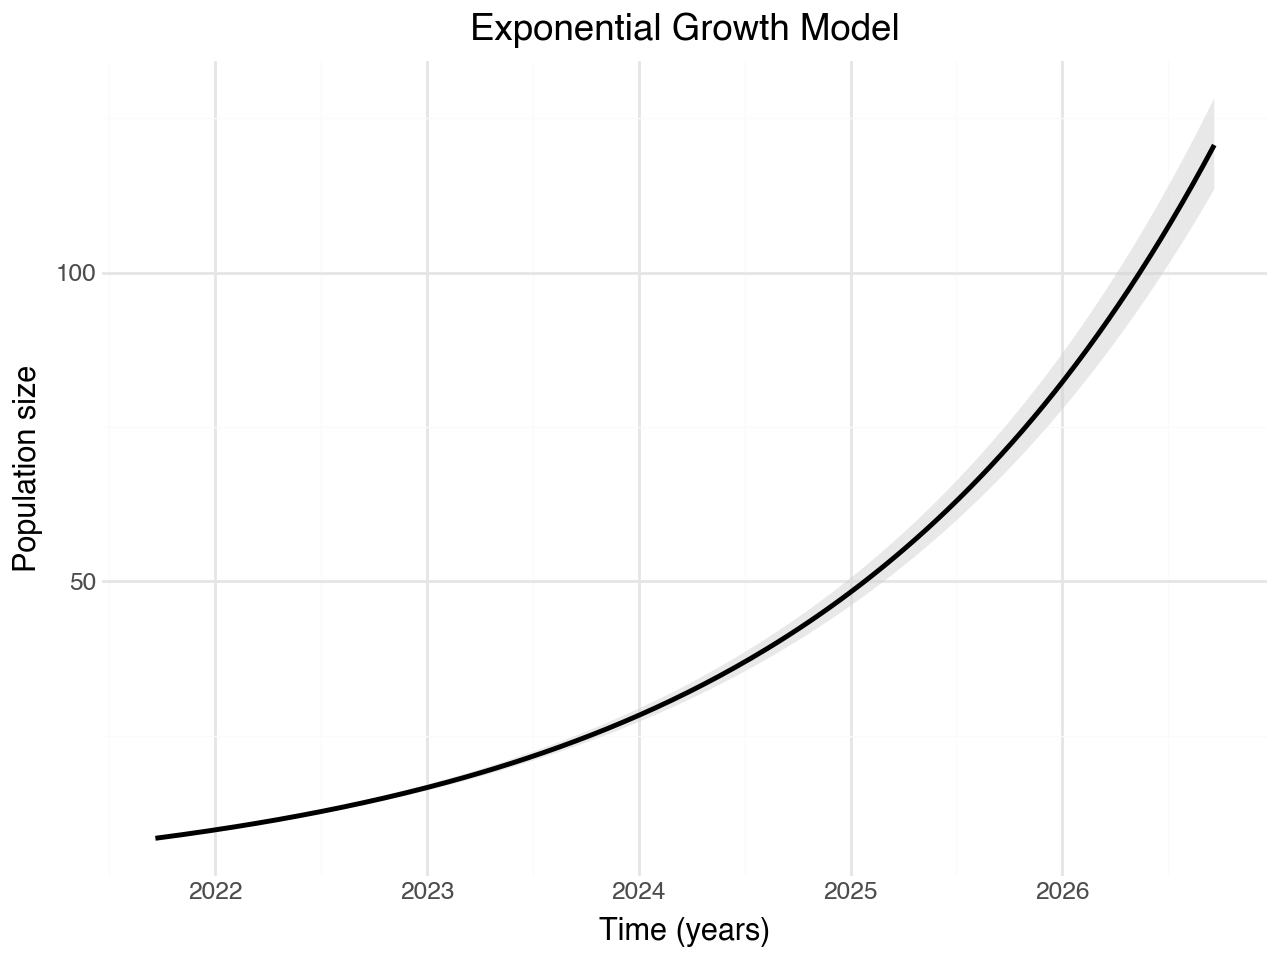

In [208]:
# Plot exponential growth

exp_plot = (ggplot(df, aes(x="time"))
     + geom_ribbon(aes(ymin="lower", ymax="upper"), fill="lightgrey", alpha=0.5)
     + geom_line(aes(y="mean"),color="black",size=1)
     + labs(x="Time (years)", y="Population size", title="Exponential Growth Model")
     + theme_minimal()
)

exp_plot.show()

In [209]:
# SKYGRID

In [210]:
SKYGRIDLOG = "/Users/claramal/Desktop/Moncla_Lab/H5-avian-ecology/BEAST/empirical_trees/results/2025-07-08_nov2021-2024_ha_empirical_skygrid_thorney/NAm_wild-aves_nov2021-2024_ha_empirical_thorney_2025-07-08_combined.log"

In [211]:
skg_logdf = pd.read_csv(SKYGRIDLOG, sep = "\t")

In [236]:
# Calculate the population size for each bin

def calculate_grid_logPopSize(dtfm, end_date, cutoff, n_bins):

    skygrid_popSize = {}
    logPopSize_columns = []
    mean_popSize = []
    lower_popSize = []
    upper_popSize = []

    for i in dtfm.columns:
        if "skygrid.logPopSize" in i:
            logPopSize_columns.append(i)

    print(len(logPopSize_columns))

    # Set a date for each bin (Chat GPT) 

    begin = end_date - cutoff
    end = end_date
    bins = n_bins
    dates = list(np.linspace(begin, end, num = bins))
    # dates = pd.date_range(start=START_DATE,end=END_DATE,periods=N_BINS) # if dates are datetime objects
    # print(dates)
    # print(len(dates))

    for k in logPopSize_columns:
        # coalescentEvent = float(k.replace("skyride.logPopSize", ""))
        mean = dtfm[k].mean()
        ci_lower, ci_upper = stats.t.interval(confidence=0.95, df=len(dtfm[k]) - 1, loc=mean, scale=stats.sem(dtfm[k]))
        mean_popSize.append(mean)
        lower_popSize.append(ci_lower)
        upper_popSize.append(ci_upper)
        
    skygrid_popSize = {"date":dates, "lowerHPD_popSize": lower_popSize, "mean_popSize": mean_popSize, "upperHPD_popSize":upper_popSize}
    
    return(skygrid_popSize)

In [237]:
# Cutoff is the "height to last known TMRCA" as inputed into BEAUTI
# End date is the most recent sampling date

skygrid_popSize = calculate_grid_logPopSize(skg_logdf, 2024.9262295081967, 3.0902, 37)

37


In [241]:
skg_df = pd.DataFrame(skygrid_popSize)#.T.reset_index()

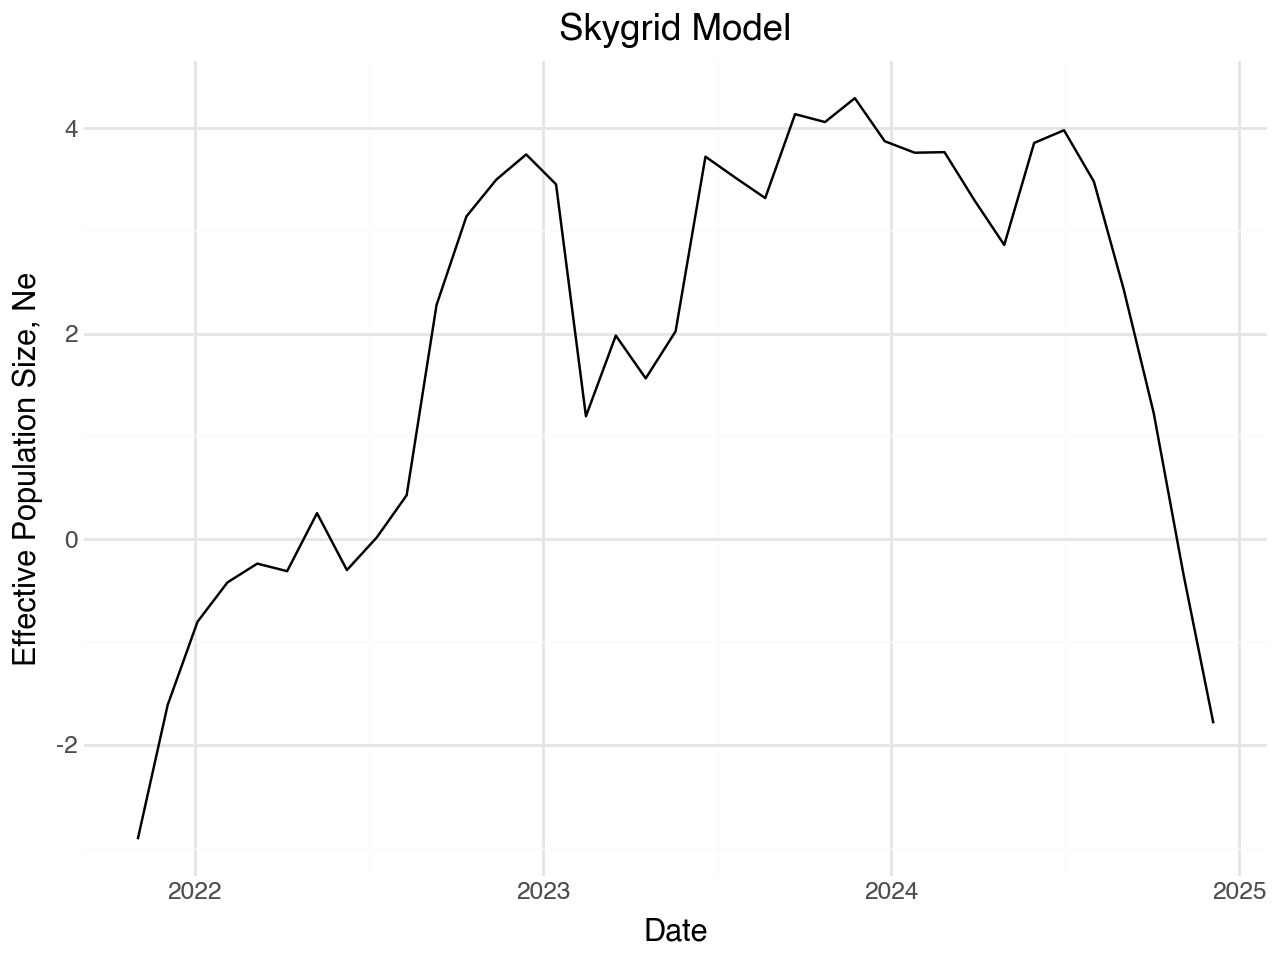

In [256]:
skygrid_plot = (
    ggplot()
    + geom_line(skg_df, aes(x="date", y="mean_popSize"), color = "black")
    # + geom_ribbon(skg_df, aes(x="date", ymin = "lowerHPD_popSize", ymax = "upperHPD_popSize"), fill = "lightgrey", color = None)
    + labs(x = "Date", y = "Effective Population Size, Ne", title = "Skygrid Model")
    + theme_minimal()
)

skygrid_plot.show()

In [248]:
# SKYRIDE

In [249]:
SKYRIDELOG = "/Users/claramal/Desktop/Moncla_Lab/H5N5-mini-project/BEAST/empirical_trees/results/A6_concat_genome_skyride_2025-12-19/A6_concat_genome_skyride_2025-12-19_combined.log"

In [250]:
skr_logdf = pd.read_csv(SKYRIDELOG, sep = "\t")

In [251]:
# Average each logPopSize column

def calculate_ride_logPopSize(dtfm):

    logPopSize_columns = []
    skyride_popSize = {}

    for i in dtfm.columns:
        if "skyride.logPopSize" in i:
            logPopSize_columns.append(i)

    print(len(logPopSize_columns))

    for k in logPopSize_columns:
        coalescentEvent = float(k.replace("skyride.logPopSize", ""))
        mean = dtfm[k].mean()
        ci_lower, ci_upper = stats.t.interval(confidence=0.95, df=len(dtfm[k]) - 1, loc=mean, scale=stats.sem(dtfm[k]))
        
        skyride_popSize[coalescentEvent] = {"meanPopSize": mean, "lowerPopSize": ci_lower, "upperPopSize": ci_upper}
    
    return(skyride_popSize)

In [252]:
skyride_popSize = calculate_ride_logPopSize(skr_logdf)

333


In [253]:
skr_df = pd.DataFrame(skyride_popSize).T.reset_index()

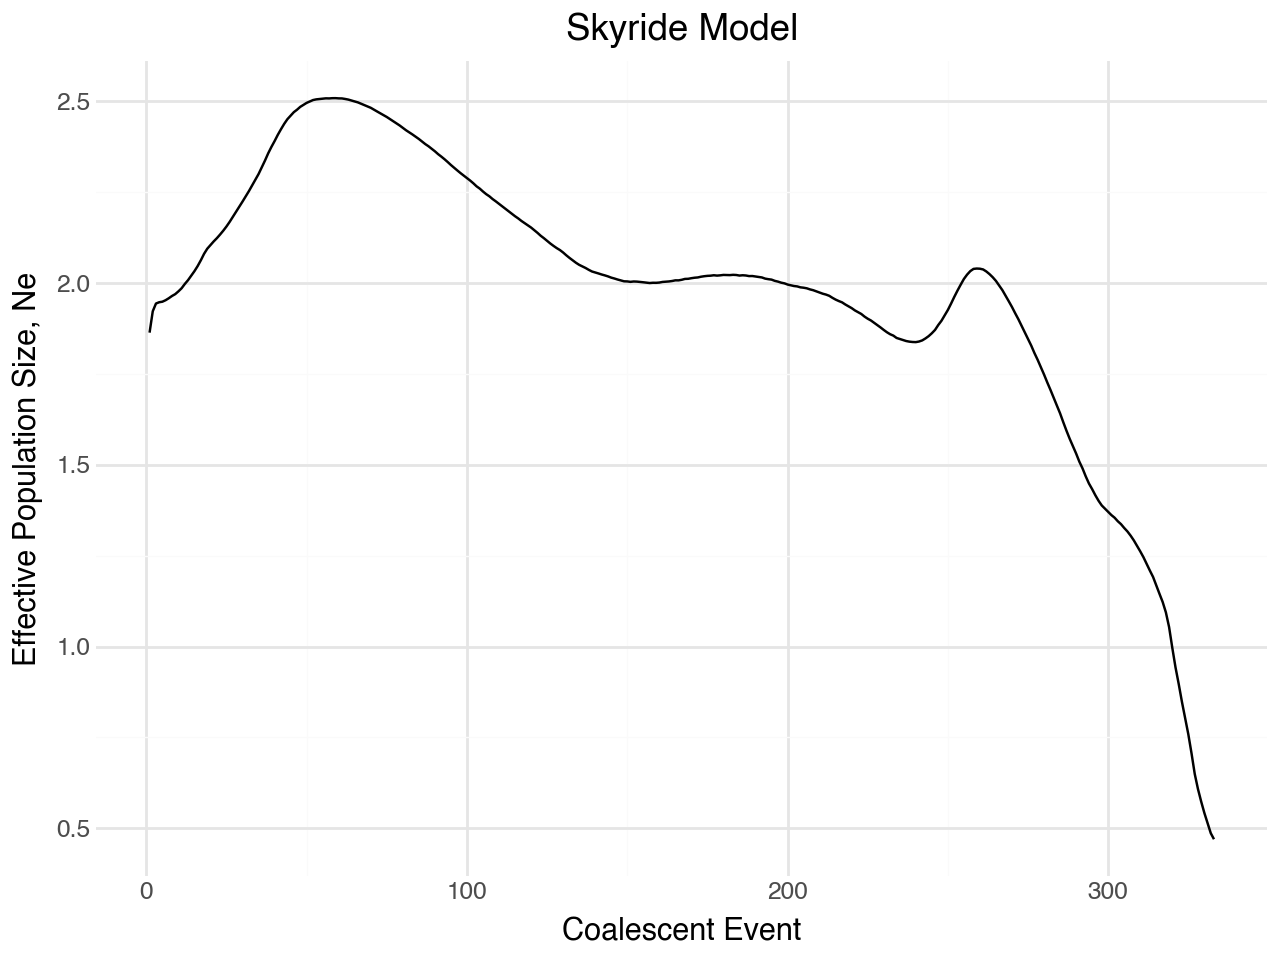

In [254]:
skyride_plot = (
    ggplot()
    + geom_line(skr_df, aes(x="index", y="meanPopSize"), color = "black")
    # + geom_ribbon(skr_df, aes(x="index", ymin = "lowerPopSize", ymax = "upperPopSize"), fill = "lightgrey", color = None)
    + labs(x = "Coalescent Event", y = "Effective Population Size, Ne", title = "Skyride Model")
    + theme_minimal()
)

skyride_plot.show()